In [1]:
import gayum
import plotnine as p9
from plotnine.data import mtcars
import numpy as np

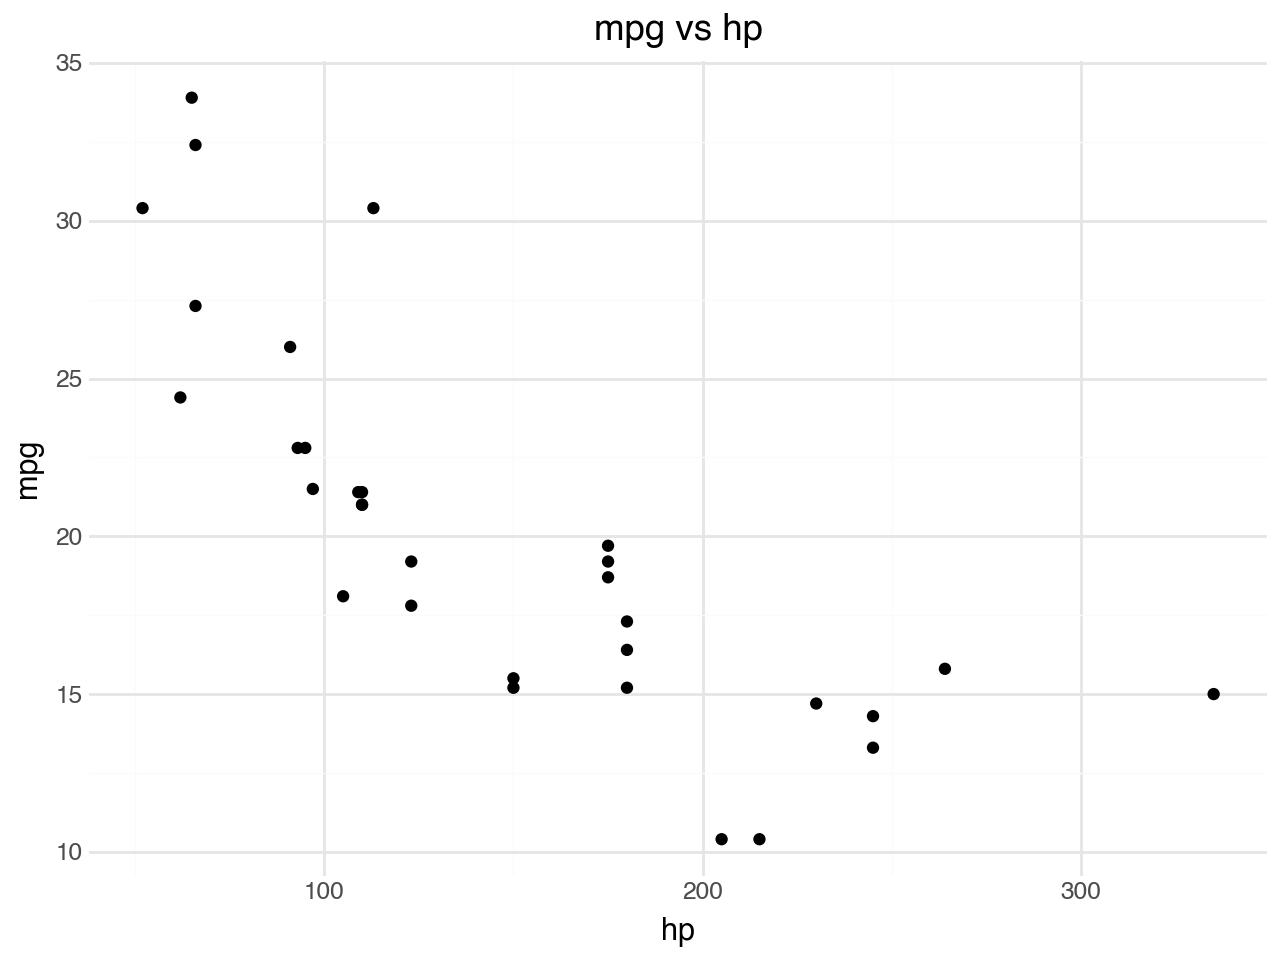

In [2]:
(
    p9.ggplot()
    + p9.geom_point(data=mtcars, mapping=p9.aes(x='hp', y='mpg'))
    + p9.theme_minimal()
    + p9.labs(title='mpg vs hp')
).show()

In [3]:

f = gayum.Formula(response='mpg', terms=gayum.terms.s('hp'), df=mtcars)
model = gayum.GAM(formula=f)

X, y = mtcars[['hp']], mtcars[['mpg']]
model = model.fit(X, y)

pred_df = mtcars[['hp', 'mpg']]
pred_df['pred'] = model.predict(X)

rmse = np.sqrt(np.mean((pred_df["mpg"] - pred_df["pred"]) ** 2))

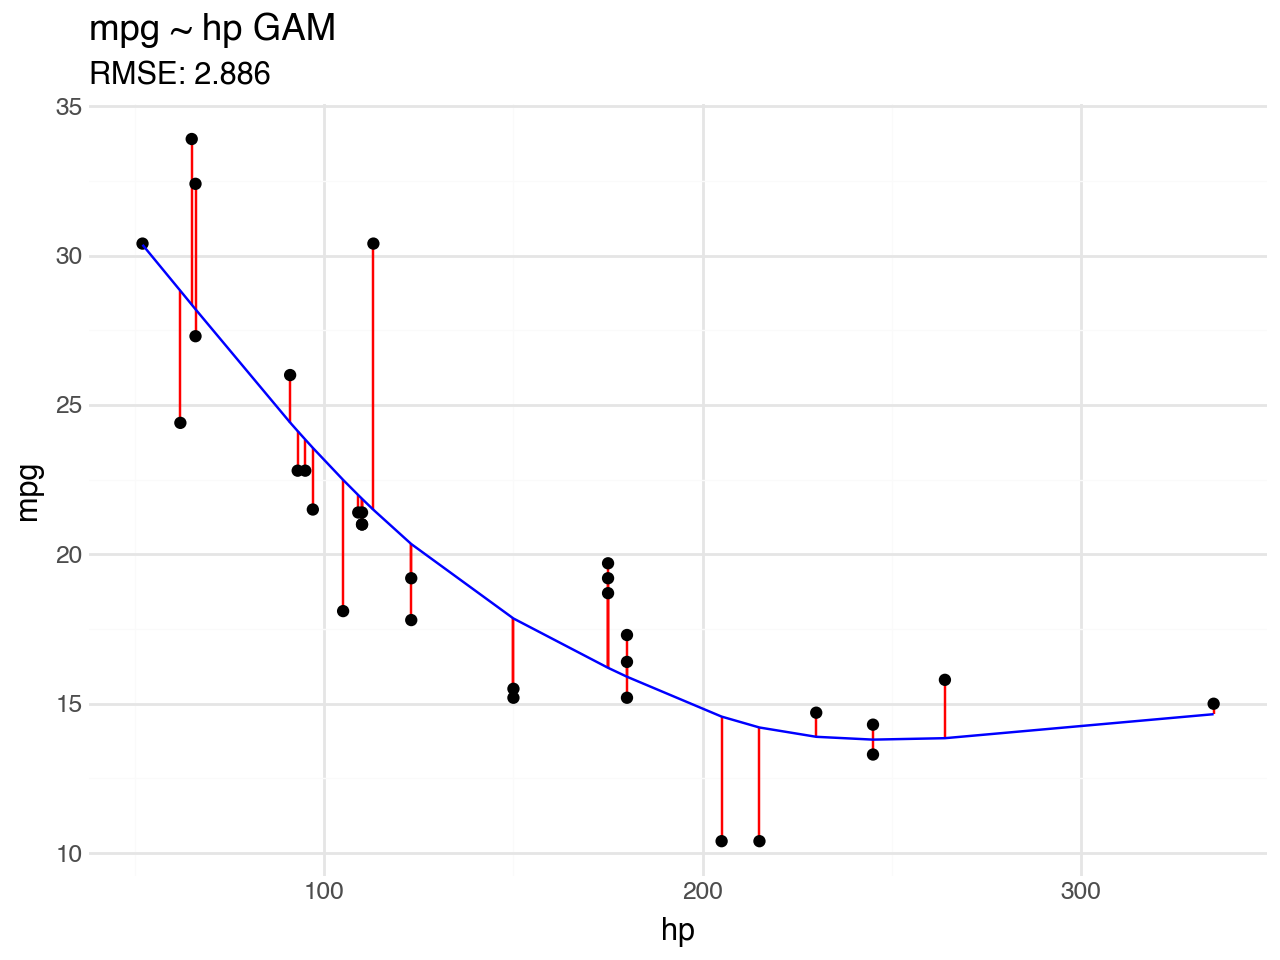

In [4]:
(
    p9.ggplot()
    + p9.geom_segment(data=pred_df, mapping=p9.aes(x='hp', xend='hp', y='mpg', yend='pred'), color='red')
    + p9.geom_point(data=pred_df, mapping=p9.aes(x='hp', y='mpg'))
    + p9.geom_line(data=pred_df, mapping=p9.aes(x='hp', y='pred'), color='blue')
    + p9.theme_minimal()
    + p9.labs(title='mpg ~ hp GAM', subtitle=f'RMSE: {rmse:.3f}')
).show()

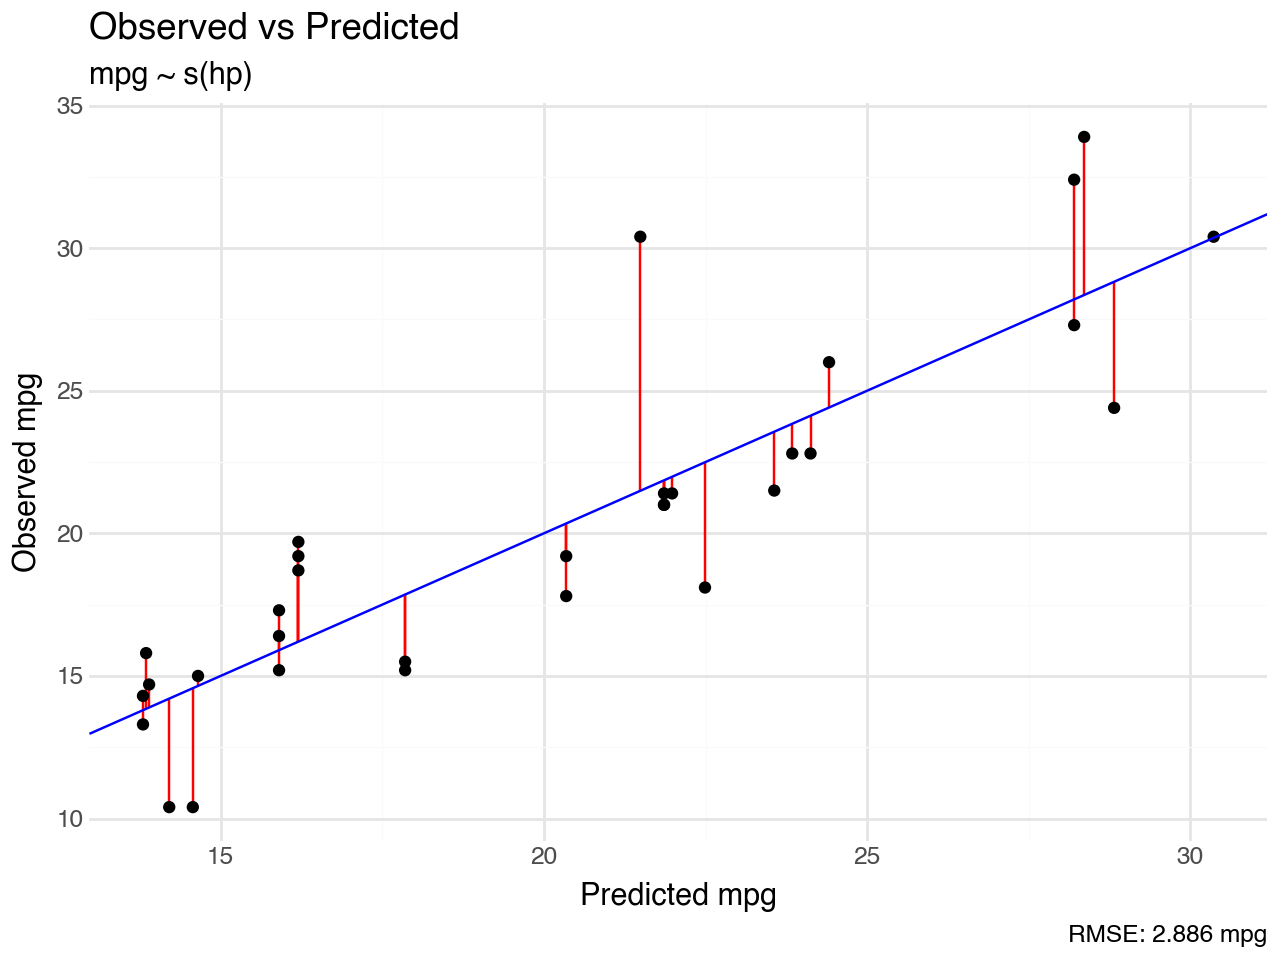

In [5]:
pred_df['resid'] = pred_df['mpg'] - pred_df['pred']

(
    p9.ggplot(pred_df, p9.aes(x='pred', y='mpg'))
    + p9.geom_segment(mapping=p9.aes(x='pred', y='pred', xend='pred', yend='mpg'), color='red')
    + p9.geom_point()
    + p9.geom_abline(intercept=0, slope=1, color='blue')
    + p9.theme_minimal()
    + p9.labs(
        title='Observed vs Predicted',
        subtitle='mpg ~ s(hp)',
        caption=f'RMSE: {rmse:.3f} mpg',
        x='Predicted mpg',
        y='Observed mpg'
    )
).show()